# Sentiment analysis of Spanish Amazon product reviews

## The problem

Online marketplaces accumulate customer opinion faster than anyone can read it. Each review
carries a star rating from 1 to 5, which is easy to aggregate but says only *how* satisfied
the customer was. The text says *why*, and it is the part nobody can process at scale.

Two questions follow from that gap, and this project addresses both:

1. **Can the sentiment be recovered from the text alone?** If a model can tell a satisfied
   customer from a dissatisfied one by reading the review, the same model can score any
   customer text that carries no rating at all.
2. **Can the corpus be queried in natural language?** Aggregating star averages answers
   *what* is happening. Asking *why are customers returning this product?* requires reading
   the reviews, which is exactly what does not scale.

## The data

[Amazon Reviews Multi](https://www.kaggle.com/datasets/mexwell/amazon-reviews-multi), a
public corpus of Amazon reviews distributed as three files (`train`, `validation`, `test`)
covering six languages. **Only the Spanish reviews are used**, which amounts to 210,000
reviews.

| Column | Content |
|---|---|
| `review_body` | Free text of the review |
| `review_title` | Title written by the customer |
| `stars` | Rating from 1 to 5, from which the target label is derived |
| `product_category` | Product category, e.g. `electronics`, `home`, `apparel` |
| `product_id`, `reviewer_id` | Anonymised identifiers |
| `review_id`, `language` | Review identifier and language code |

The star rating provides the label, grouped into **three sentiment classes**:

| Sentiment | Stars |
|---|---|
| Negative | 1, 2 |
| Neutral | 3 |
| Positive | 4, 5 |

Predicting the exact star level is deliberately not the goal. The difference between 4 and 5
stars is largely a matter of each customer's personal scale rather than of anything the review
says, so a model asked to separate them is being set an ambiguous task. The three-way grouping
keeps the distinction that a business would actually act on, and the neutral class is retained
rather than discarded because a lukewarm opinion is a real outcome, not an absence of one.

## Objectives

**Sentiment classification.** Predict whether a review expresses a negative, neutral or
positive experience from its text alone.

**Retrieval-augmented question answering (RAG).** Build a system that answers questions about
the corpus by retrieving the reviews relevant to the question and grounding the answer in
them, so that a query returns evidence drawn from real customer opinions rather than a
generic response.

## Why it is useful

- Sentiment scoring extends to any customer text with no rating attached: support tickets,
  survey responses, social media mentions.
- A product whose incoming reviews turn negative can be flagged before its star average moves,
  since an average built on hundreds of past ratings reacts slowly.
- Retrieval turns the reasons behind a score into something searchable. *What do customers
  complain about in this category?* becomes a query instead of a week of manual reading.

## Methodology

The modelling follows a progressive path, where each stage is measured against the previous
one so that any added complexity has to justify itself:

1. **Data quality and exploratory analysis.** Establish what the corpus contains, how the
   ratings are distributed, how long the reviews are and what vocabulary they use.
2. **Category-level analysis.** Which product categories concentrate the best and worst
   opinions, and how sentiment relates to review length and writing style, supported by
   statistical tests rather than by eyeballing averages.
3. **Baseline.** A bag-of-words representation with a linear classifier. It is fast,
   interpretable, and it sets the floor that anything more sophisticated must beat.
4. **Pretrained language model.** A transformer pretrained on Spanish, fine-tuned on this
   corpus, which unlike the baseline can use word order and context.
5. **Formal comparison.** Both models evaluated on the same held-out data, comparing macro and
   per-class F1, accuracy, confusion matrices and inference time. Grouping the ratings leaves
   the three classes unevenly represented, so macro F1 rather than accuracy is the headline
   metric: a model that never predicts the neutral class would still be right most of the time.
   And a model that is marginally better but far slower is not automatically the right
   choice.
6. **Embedding visualisation.** Projecting the learned representations to two dimensions to
   see whether the three sentiment classes separate, and where they overlap.
7. **Retrieval system.** A vector database over the reviews, used to answer questions grounded
   in the retrieved text.



# Libraries

In [161]:
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
import random
import numpy as np
import emoji

# NLTK 3.10.1 refuses to import any dependency that resolves to a path inside the
# current working directory. The virtual environment lives in ./.venv, so every
# NLTK dependency in site-packages is flagged as untrusted and the import fails.
# Loading them here, before NLTK itself, keeps that check from triggering.
import regex, defusedxml.ElementTree, joblib, tqdm, click

import nltk
from nltk.corpus import stopwords


# Reproducibility

In [162]:
seed = 42
random.seed(seed)
np.random.seed(seed)

# Data

The dataset ships as three separate files, `train.csv`, `validation.csv` and `test.csv`,
already partitioned by its authors.

**The three are merged into a single DataFrame.** Exploratory analysis describes a corpus, and
describing a pre-split fragment of it would give a partial and possibly misleading picture:
every quality check would have to be repeated three times, and any statistic would be
conditioned on a partition that has nothing to do with the phenomenon being studied.

**A `split` column is added before merging**, recording which file each row came from. This is
what makes the merge safe rather than destructive: the original partition is preserved inside
the data and can be reproduced exactly at any point, while the corpus can be treated as one
table for analysis. Without that column the merge would be irreversible, and the authors'
partition, which exists so that results are comparable across studies, would be lost.

Each file contains reviews in six languages. Only Spanish is kept.


In [163]:
path = kagglehub.dataset_download("mexwell/amazon-reviews-multi")

print("Path to dataset files:", path)

Path to dataset files: /home/alejandro/.cache/kagglehub/datasets/mexwell/amazon-reviews-multi/versions/1


In [164]:
train = pd.read_csv(f"{path}/train.csv")
test = pd.read_csv(f"{path}/test.csv")
validation = pd.read_csv(f"{path}/validation.csv")

train['split'] = 'train'
test['split'] = 'test'
validation['split'] = 'validation'

In [165]:
df = pd.concat([train, test, validation], ignore_index=True)

df.head()

,Unnamed: 0,review_id,product_id,reviewer_id,stars,review_body,review_title,language,product_category,split
0,0,de_0203609,product_de_0865382,reviewer_de_0267719,1,Armband ist leider nach 1 Jahr kaputt gegangen,Leider nach 1 Jahr kaputt,de,sports,train
1,1,de_0559494,product_de_0678997,reviewer_de_0783625,1,In der Lieferung war nur Ein Akku!,EINS statt ZWEI Akkus!!!,de,home_improvement,train
2,2,de_0238777,product_de_0372235,reviewer_de_0911426,1,"Ein Stern, weil gar keine geht nicht. Es hande...",Achtung Abzocke,de,drugstore,train
3,3,de_0477884,product_de_0719501,reviewer_de_0836478,1,"Dachte, das wären einfach etwas festere Binden...",Zu viel des Guten,de,drugstore,train
4,4,de_0270868,product_de_0022613,reviewer_de_0736276,1,Meine Kinder haben kaum damit gespielt und nac...,Qualität sehr schlecht,de,toy,train


# Data exploration

The corpus is filtered to Spanish and saved before anything else, so the raw subset is always
recoverable. The checks that follow are the basics: size, column types, missing values,
duplicated rows, and how the reviews distribute across the three original files. Nothing is
modified at this stage except the removal of the residual index column.


In [166]:
df_spanish = df[df['language'] == 'es'].copy()

df_spanish.to_csv('amazon_reviews_spanish.csv', index=False)

In [167]:
df_spanish.head()

,Unnamed: 0,review_id,product_id,reviewer_id,stars,review_body,review_title,language,product_category,split
400000,400000,es_0491108,product_es_0296024,reviewer_es_0999081,1,Nada bueno se me fue ka pantalla en menos de 8...,television Nevir,es,electronics,train
400001,400001,es_0869872,product_es_0922286,reviewer_es_0216771,1,"Horrible, nos tuvimos que comprar otro porque ...",Dinero tirado a la basura con esta compra,es,electronics,train
400002,400002,es_0811721,product_es_0474543,reviewer_es_0929213,1,Te obligan a comprar dos unidades y te llega s...,solo llega una unidad cuando te obligan a comp...,es,drugstore,train
400003,400003,es_0359921,product_es_0656090,reviewer_es_0224702,1,"No entro en descalificar al vendedor, solo pue...",PRODUCTO NO RECIBIDO.,es,wireless,train
400004,400004,es_0068940,product_es_0662544,reviewer_es_0224827,1,Llega tarde y co la talla equivocada,Devuelto,es,shoes,train


In [168]:
df_spanish.tail()

,Unnamed: 0,review_id,product_id,reviewer_id,stars,review_body,review_title,language,product_category,split
1244995,14995,es_0179515,product_es_0158275,reviewer_es_0273644,5,Me ha encantado la cesta. Ha llegado impecable...,guadalupe,es,home,validation
1244996,14996,es_0894902,product_es_0953259,reviewer_es_0153773,5,Desempeña su función correctamente,calidad precio,es,camera,validation
1244997,14997,es_0760496,product_es_0731995,reviewer_es_0171091,5,Me ha encantado la diadema! Las flores son tal...,Excelente,es,toy,validation
1244998,14998,es_0178380,product_es_0402051,reviewer_es_0686937,5,"A mi me gustan mucho las fundas TPU, ya que so...",Genial,es,wireless,validation
1244999,14999,es_0810087,product_es_0684221,reviewer_es_0613091,5,El artículo ha cumplido con las expectativas q...,Buena calidad,es,apparel,validation


In [169]:
df_spanish.info()

<class 'pandas.DataFrame'>
Index: 210000 entries, 400000 to 1244999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   Unnamed: 0        210000 non-null  int64
 1   review_id         210000 non-null  str  
 2   product_id        210000 non-null  str  
 3   reviewer_id       210000 non-null  str  
 4   stars             210000 non-null  int64
 5   review_body       210000 non-null  str  
 6   review_title      210000 non-null  str  
 7   language          210000 non-null  str  
 8   product_category  210000 non-null  str  
 9   split             210000 non-null  str  
dtypes: int64(2), str(8)
memory usage: 17.6 MB


In [170]:
df_spanish.describe()

,Unnamed: 0,stars
count,210000.000000,210000.000000
mean,476785.214286,3.000000
std,118122.098049,1.414217
min,10000.000000,1.000000
25%,442499.750000,2.000000
50%,494999.500000,3.000000
75%,547499.250000,4.000000
max,599999.000000,5.000000


In [171]:
df_spanish['split'].value_counts()

split
train         200000
test            5000
validation      5000
Name: count, dtype: int64

In [172]:
df_spanish.isnull().mean() * 100

Unnamed: 0          0.0
review_id           0.0
product_id          0.0
reviewer_id         0.0
stars               0.0
review_body         0.0
review_title        0.0
language            0.0
product_category    0.0
split               0.0
dtype: float64

In [173]:
df_spanish.duplicated().sum()

np.int64(0)

The checks above modify nothing. The only change made in this section is dropping
`Unnamed: 0`, whose values were just shown to be a residual index carrying no information.


In [174]:
df_spanish = df_spanish.drop(columns=['Unnamed: 0'])

In [175]:
df_spanish.head()

,review_id,product_id,reviewer_id,stars,review_body,review_title,language,product_category,split
400000,es_0491108,product_es_0296024,reviewer_es_0999081,1,Nada bueno se me fue ka pantalla en menos de 8...,television Nevir,es,electronics,train
400001,es_0869872,product_es_0922286,reviewer_es_0216771,1,"Horrible, nos tuvimos que comprar otro porque ...",Dinero tirado a la basura con esta compra,es,electronics,train
400002,es_0811721,product_es_0474543,reviewer_es_0929213,1,Te obligan a comprar dos unidades y te llega s...,solo llega una unidad cuando te obligan a comp...,es,drugstore,train
400003,es_0359921,product_es_0656090,reviewer_es_0224702,1,"No entro en descalificar al vendedor, solo pue...",PRODUCTO NO RECIBIDO.,es,wireless,train
400004,es_0068940,product_es_0662544,reviewer_es_0224827,1,Llega tarde y co la talla equivocada,Devuelto,es,shoes,train


### Structural inspection: findings

- The Spanish subset contains **210,000 reviews**, distributed as 200,000 / 5,000 / 5,000
  across the three original files.
- **No missing values** in any column, and **no fully duplicated rows**.
- `Unnamed: 0` is a residual index inherited from the source CSVs. Its values range from
  10,000 to 599,999 and overlap across files, so it identifies nothing and is dropped.
- The `language` column is constant (`es`) after filtering. It is kept only for traceability.


## Target distribution

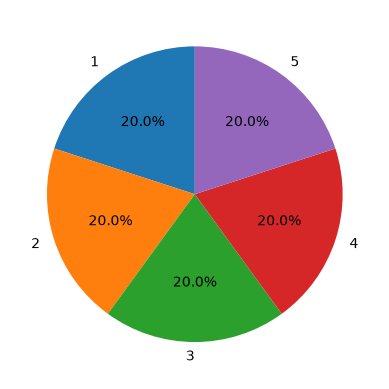

In [176]:
stars = df_spanish['stars'].astype(str)
counts = stars.value_counts().sort_index()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
plt.show()

The five rating levels are the raw label, but the target of this project is the three-way
sentiment class defined in the introduction. The `sentiment` column derives it from `stars`
through an explicit mapping, so the correspondence is visible in the code rather than hidden
in a condition. The second pie chart shows what the grouping does to the class proportions.


In [177]:
SENTIMENT = {1: 'negative', 2: 'negative', 3: 'neutral', 4: 'positive', 5: 'positive'}

df_spanish['sentiment'] = df_spanish['stars'].map(SENTIMENT)

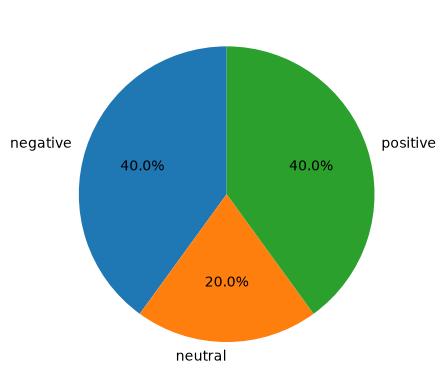

In [178]:
sentiments = df_spanish['sentiment']
counts = sentiments.value_counts().sort_index()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
plt.show()

### Target distribution: findings

The five rating levels are **perfectly balanced**: 42,000 reviews per level, mean exactly
3.000 and standard deviation 1.4142.

This balance is **artificial**. The corpus was assembled by design with equal class sizes and
does not reflect the real distribution of Amazon reviews, which is heavily skewed towards 5
stars. Any statement about "the proportion of dissatisfied customers" derived from this
dataset would therefore be invalid: the dataset says nothing about how common each rating is
in reality.

What the balance does allow is a clean comparison of the language used at each rating level,
since no level is over-represented in the vocabulary counts that follow.

**The balance does not survive the grouping into sentiment classes.** The `sentiment` column
maps 1-2 to negative, 3 to neutral and 4-5 to positive, which gives 84,000 negative, 42,000
neutral and 84,000 positive reviews: a 2:1:2 proportion, as the second pie chart shows. Two
consequences follow for the modelling stages:

- **Accuracy stops being a safe headline metric.** A model that never predicts the neutral
  class would still be right about 80 % of the time. Macro F1 and per-class F1 are the metrics
  that expose that failure mode.
- **Whether to reweight the neutral class becomes a real decision**, where on the five-level
  scale it would have been unnecessary.


# Text analysis

Cleaning is applied to **copies** of the text, never to the original columns.

| Column | Content |
|---|---|
| `review_body`, `review_title` | Original text, never modified |
| `body_clean`, `title_clean` | Normalised text, used for the analysis below |

Keeping the originals serves three purposes: every cleaning step can be verified by reading
the before and after side by side, further variants can be derived without reprocessing the
raw files, and any later use that needs to show a review as the customer wrote it still has
the untouched text available.

Each diagnostic below follows the same procedure: build a mask, measure how many reviews are
affected, read a sample of the matches, and only then decide on a rule. Rules are justified
by measured prevalence, not by convention. A transformation that fixes a problem the corpus
does not have adds risk without adding value.

**Every artefact found in this corpus is resolved by dropping the affected rows**, and the
same three reasons apply in each case:

- **The counts are small.** No artefact reaches 0.4 % of the corpus, so removing the rows
  cannot shift any distribution or any later metric.
- **Dropping avoids introducing artificial text.** Rewriting an artefact means inserting
  strings that no customer wrote. Those strings are rare and concentrated in specific reviews,
  which is exactly the shape of a spurious feature a model can latch onto. Removing the row
  leaves the remaining text exactly as it was written.
- **What remains is more than enough.** The corpus keeps over 208,000 reviews after cleaning.
  Nothing in this project is limited by sample size, so preserving every last row has no value
  worth trading complexity for.

The alternative, transforming each artefact in place, would mean a separate rule per case,
each one to be justified, tested and maintained, in exchange for a fraction of a percent of
additional data. That trade is not worth making here.


## Emojis

Emojis are detected with `emoji.emoji_count`, which works from the official Unicode emoji
table rather than from a hand-written character range, so compound emojis and skin-tone
modifiers are counted correctly. Prevalence is measured separately on the body and the title,
a sample of the matches is read before any decision is taken, and the conversion is verified
afterwards by running the same count again on the cleaned columns.


In [179]:
mask_emoji = df_spanish['review_body'].apply(emoji.emoji_count) > 0
mask_emoji_title = df_spanish['review_title'].apply(emoji.emoji_count) > 0


In [180]:
df_spanish[mask_emoji][['review_body']].sample(10, random_state=seed)

,review_body
599557,Hermética!! Va muy muy bien y es súper bonita 😜
407040,👎🏻 no sé gana nada d peso
447393,"Pierde muy rápido el Bluetooth, se desparejan ..."
443705,Me es difícil escribir una opinión de este pro...
453321,"Son grandes, sobre todo demasiado anchas. Una ..."
448466,Los cuencos muy pequeños para el tamaño de mi ...
554558,"Pedí uno para mí mujer y vino defectuoso, meno..."
569087,"Muy bueno y bonito, pero el primer día la prof..."
472742,Menos de un mes de uso y ya empieza a desinteg...
429166,"Es de plástico y muy fina, es igual que no pon..."


In [181]:
df_spanish[mask_emoji_title][['review_title']].sample(10, random_state=seed)

,review_title
504214,Champú.. 🤷‍♂️
1212217,"Bien para música, llamadas ☹️"
591260,Perfecto 👌🏼
559890,👌🏻
503790,☹️
574774,Correcto 👍🏼
586313,Compra 💯%
555074,Buena..😁
575338,Bonitas 👍🏻
528987,👌🏻


In [182]:
print("Number of reviews with emojis in the body:", mask_emoji.sum())
print("Number of reviews with emojis in the title:", mask_emoji_title.sum())

Number of reviews with emojis in the body: 786
Number of reviews with emojis in the title: 351


In [183]:
print(f"Number of reviews with emojis in the body: {mask_emoji.mean()*100:.2f}%")
print(f"Number of reviews with emojis in the title: {mask_emoji_title.mean()*100:.2f}%")

Number of reviews with emojis in the body: 0.37%
Number of reviews with emojis in the title: 0.17%


Measurement ends here and the rows carrying the artefact are removed. The mask covers the
body and the title, so a review is dropped if either field contains an emoji.


In [184]:
df_spanish = df_spanish[~mask_emoji & ~mask_emoji_title].copy()

### Emojis: findings and decision

| | `review_body` | `review_title` |
|---|---|---|
| Reviews containing emojis | 786 (0.37 %) | 351 (0.17 %) |

**Decision: drop the affected rows.** A review is removed if an emoji appears in the body or
in the title, which takes out 1,098 rows, 0.52 % of the corpus.

Converting the characters to their written description was considered, and the `emoji` library
does it reliably from the official Unicode table. It was rejected for two reasons.

**It inserts text no customer wrote.** An alias such as `:cara_llorando_de_risa:` is not
Spanish; it is a token that exists in roughly one review in three hundred and is strongly tied
to whichever ratings those reviews happen to carry. A rare string that correlates with a class
is the classic shape of a shortcut feature, and the gain it might offer does not justify
handing the model that opportunity.

**The volume does not justify the machinery.** Keeping 1,098 rows means carrying a conversion
step, its verification, and the decisions that hang off it, such as what to do with skin-tone
modifiers or with the residual symbols that fall outside the official emoji table. That is a
permanent addition to the pipeline in exchange for half a percent of the data.

Some of the removed rows do lose real information: a handful of titles consist exclusively of
emojis, and for those the emoji was the whole message. Losing them is the accepted cost of the
simpler pipeline, and at 165 titles it changes nothing measurable.


## URLs

In [185]:
URL_PATTERN = r"(?i)\b(?:https?://|www\.)\S+"


mask_url_body = df_spanish['review_body'].str.contains(URL_PATTERN, regex=True)
mask_url_title = df_spanish['review_title'].str.contains(URL_PATTERN, regex=True)

In [186]:
print(f"Number of reviews with URLs in the body: {mask_url_body.sum()}")
print(f"Number of reviews with URLs in the title: {mask_url_title.sum()}")

Number of reviews with URLs in the body: 1
Number of reviews with URLs in the title: 0


In [187]:
df_spanish = df_spanish[~mask_url_body & ~mask_url_title].copy()

In [188]:
df_spanish.shape

(208901, 10)

### URLs: findings and decision

| | `review_body` | `review_title` |
|---|---|---|
| Reviews containing URLs | 1 | 0 |

**Decision: drop the affected row.**

One occurrence is a negligible quantity: removing it cannot affect any result. Writing a
substitution rule for a single case would add permanent code to the pipeline in exchange for
nothing, so the row is dropped, in line with the criterion set out above.


## Email addresses

In [189]:
EMAIL_PATTERN = r"(?i)\b[\w-]+@[\w-]+\.(?:com|es|net|org|info|io|store|online)\b"

mask_email_body = df_spanish['review_body'].str.contains(EMAIL_PATTERN, regex=True)
mask_email_title = df_spanish['review_title'].str.contains(EMAIL_PATTERN, regex=True)

In [190]:
print(f"Number of reviews with emails in the body: {mask_email_body.sum()}")
print(f"Number of reviews with emails in the title: {mask_email_title.sum()}")

Number of reviews with emails in the body: 0
Number of reviews with emails in the title: 0


### Email addresses: findings and decision

| | `review_body` | `review_title` |
|---|---|---|
| Reviews containing email addresses | 0 | 0 |

**Decision: no treatment required.** The phenomenon does not occur in this corpus. This also
means the dataset carries no personal contact details in its free text.


## HTML

In [191]:
HTML_TAG_PATTERN = r"<[^>]+>"
HTML_ENTITY_PATTERN = r"&[a-zA-Z]+;|&#\d+;"

mask_html_tag_body = df_spanish['review_body'].str.contains(HTML_TAG_PATTERN, regex=True)
mask_html_tag_title = df_spanish['review_title'].str.contains(HTML_TAG_PATTERN, regex=True)

mask_html_ent_body = df_spanish['review_body'].str.contains(HTML_ENTITY_PATTERN, regex=True)
mask_html_ent_title = df_spanish['review_title'].str.contains(HTML_ENTITY_PATTERN, regex=True)

print(f"Number of reviews with HTML tags in the body: {mask_html_tag_body.sum()}")
print(f"Number of reviews with HTML tags in the title: {mask_html_tag_title.sum()}")
print(f"Number of reviews with HTML entities in the body: {mask_html_ent_body.sum()}")
print(f"Number of reviews with HTML entities in the title: {mask_html_ent_title.sum()}")


Number of reviews with HTML tags in the body: 2
Number of reviews with HTML tags in the title: 0
Number of reviews with HTML entities in the body: 0
Number of reviews with HTML entities in the title: 0


In [192]:
df_spanish = df_spanish[~mask_html_tag_body & ~mask_html_tag_title & ~mask_html_ent_body & ~mask_html_ent_title].copy()


In [193]:
df_spanish.shape

(208899, 10)

### HTML: findings and decision

| | `review_body` | `review_title` |
|---|---|---|
| HTML tags | 2 | 0 |
| HTML entities | 0 | 0 |

**Decision: drop the affected rows.**

HTML markup such as `<br />` and `&amp;` is common in raw review corpora scraped from the web,
so its near-absence here is worth stating explicitly: this dataset was already sanitised
before publication, and no HTML-stripping stage is needed.

This closes the removals. The corpus goes from 210,000 reviews to **208,899**, having dropped
1,101 rows in total: 1,098 for emojis, 2 for HTML tags and 1 for a URL. That is 0.52 % of the
original, and the corpus that remains is large enough that nothing downstream is constrained
by its size.


## Whitespace

In [194]:

df_spanish['body_clean'] = (
    df_spanish['review_body'].str.replace(r"\s+", " ", regex=True).str.strip()
)
df_spanish['title_clean'] = (
    df_spanish['review_title'].str.replace(r"\s+", " ", regex=True).str.strip()
)



### Whitespace: findings and decision

No anomalous whitespace (repeated spaces, leading or trailing spaces) was found in the
original columns.

**Decision: apply the normalisation anyway.** Collapsing `\s+` to a single space and trimming
the ends costs nothing, and it is the one transformation in the pipeline that cannot introduce
anything artificial: it only removes redundant separators, never adds or rewrites a character.
It is also what defines `body_clean` and `title_clean`, the columns the rest of the analysis
uses, leaving the originals untouched.

In Python 3, `\s` on Unicode strings already covers non-breaking and typographic spaces as
well as tabs and line breaks, so this single rule also handles line breaks. The zero-width
space (`\u200b`) is the one exception and would need a separate check.


## Post-cleaning check

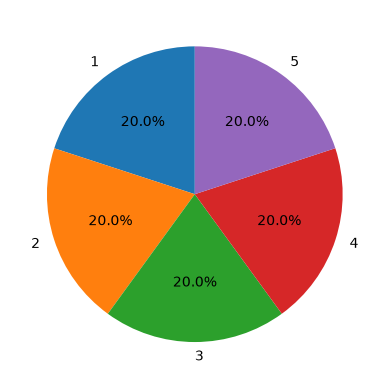

In [195]:
stars = df_spanish['stars'].astype(str)
counts = stars.value_counts().sort_index()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
plt.show()

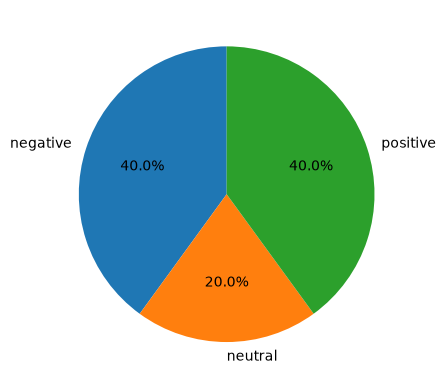

In [196]:
sentiments = df_spanish['sentiment']
counts = sentiments.value_counts().sort_index()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
plt.show()

In [197]:
stars.value_counts().sort_index()

stars
1    41727
2    41818
3    41828
4    41818
5    41708
Name: count, dtype: int64

In [198]:
sentiments.value_counts().sort_index()

sentiment
negative    83545
neutral     41828
positive    83526
Name: count, dtype: int64

In [199]:
df_spanish['body_clean'].sample(10, random_state=seed)

570590     Cuando lo vi no dude en comprarlo,me parece qu...
420162     Llega en mal estado las piezas. El montaje es ...
499206          El dvd está bien pero vino con la caja rota.
426599     la correa no se acopla bien al reloj, encima m...
500307     Como tostadora de pan, el pan queda espectacul...
416966     LA VERDAD NO LO HE PODIDO NI UTILIZAR, NUNCA E...
1241321        Dura igual que la antigua, se descarga rapido
566100     Buen precio. Plazo largo pero para tener en el...
562575      Perfecto envuelto, caja en perfectas condiciones
440281     Tardan en calentarse y se pegan. Cierto es que...
Name: body_clean, dtype: str

In [200]:
df_spanish['title_clean'].sample(10, random_state=seed)

570590         Lo compré como complemento de la granja
420162          Revisión de las piezas antes del envio
499206                           Vino con la caja rota
426599                                            MALA
500307     Lo uso exclusivamente como tostadora de pan
416966                                  NO ENCIENDE...
1241321                 Barata pero se descarga rapido
566100                        Precio bueno plazo largo
562575                                    Envio rápido
440281                 No son tan buenas como parecian
Name: title_clean, dtype: str

### After cleaning: verification

**The distribution survives the cleaning.** The five rating levels end up between 41,708 and
41,828 reviews each, a spread of 0.3 % where before they were exactly equal, and the sentiment
classes stand at 83,545 negative, 41,828 neutral and 83,526 positive. The 2:1:2 proportion is
intact and both pie charts are visually identical to the ones produced before cleaning.

That the removals left the balance in place is worth checking rather than assuming. Emojis are
not used evenly across rating levels, so dropping every review that contains one could in
principle have thinned a class more than the others. The counts above show it did not.

Reading a sample of `body_clean` and `title_clean` confirms the text is natural Spanish and
identical to the original wording. Nothing was rewritten: the only change applied to the text
itself is whitespace normalisation, and every review carrying an artefact was removed rather
than repaired.


The cleaned dataset is written to disk here. From this point on, later work can start from
`amazon_reviews_spanish_cleaned.csv` instead of re-running the download, the filtering and the
cleaning. The file keeps the original text columns alongside the cleaned ones and the derived
`sentiment` label.


In [201]:
df_spanish.to_csv('amazon_reviews_spanish_cleaned.csv', index=False)

# Text length and word frequency

Length is measured in characters on the cleaned columns, since those are the ones the rest of
the analysis uses. Each field is first summarised numerically and then shown twice: a boxplot,
which makes the spread and the outliers visible, and a histogram, which shows the shape of the
distribution. Body and title are treated separately because they are different kinds of text.


In [202]:
text_lengths = df_spanish['body_clean'].str.len()

In [203]:
text_lengths.describe()

count    208899.000000
mean        151.316440
std         132.143112
min          16.000000
25%          68.000000
50%         120.000000
75%         186.000000
max        3086.000000
Name: body_clean, dtype: float64

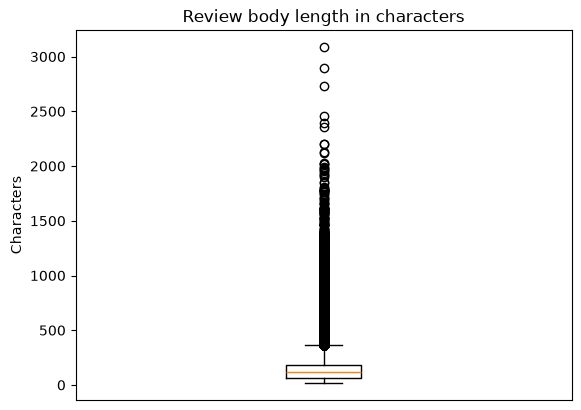

In [204]:
plt.boxplot(text_lengths)
plt.title('Review body length in characters')
plt.ylabel('Characters')
plt.xticks([])
plt.show()


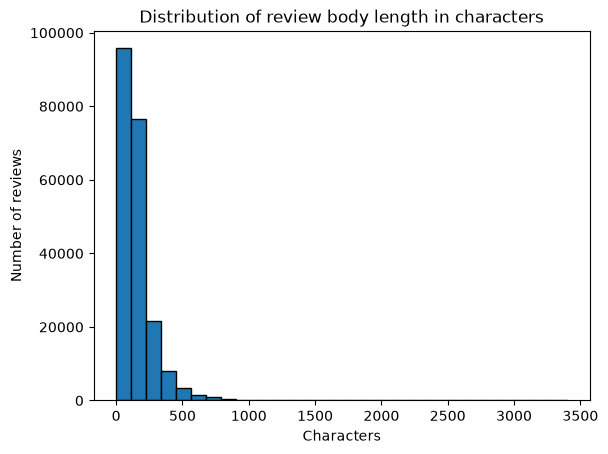

In [205]:
plt.hist(text_lengths, bins=30, edgecolor='black', range=(0, 3400))
plt.title('Distribution of review body length in characters')
plt.xlabel('Characters')
plt.ylabel('Number of reviews')
plt.show()


In [206]:
title_length = df_spanish['title_clean'].str.len()

In [207]:
title_length.describe()

count    208899.000000
mean         19.181987
std          13.422380
min           1.000000
25%          10.000000
50%          16.000000
75%          25.000000
max         128.000000
Name: title_clean, dtype: float64

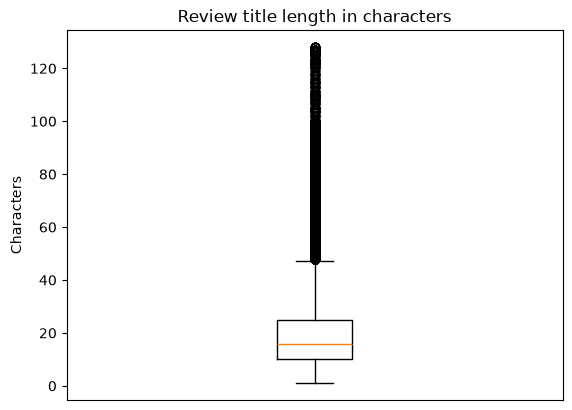

In [208]:
plt.boxplot(title_length)
plt.title('Review title length in characters')
plt.ylabel('Characters')
plt.xticks([])
plt.show()


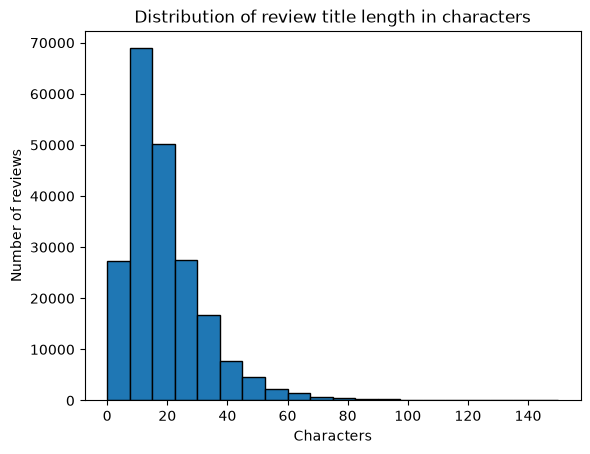

In [209]:
plt.hist(title_length, bins=20, edgecolor='black', range=(0, 150))
plt.title('Distribution of review title length in characters')
plt.xlabel('Characters')
plt.ylabel('Number of reviews')
plt.show()


### Text length: findings

| | `body_clean` | `title_clean` |
|---|---|---|
| Mean | 151.3 | 19.2 |
| Median | 120 | 16 |
| 25th percentile | 68 | 10 |
| 75th percentile | 186 | 25 |
| 95th percentile | 390 | 45 |
| 99th percentile | 665 | 68 |
| Maximum | 3,086 | 128 |
| Minimum | 16 | 1 |

**These are short texts.** A median of 120 characters is roughly twenty words, about two
sentences. A quarter of all reviews fit in 68 characters, which is a single short sentence,
and three quarters fit in 186. Titles are shorter still: a median of 16 characters, two or
three words, closer to a label than to a sentence: *Excelente*, *Devuelto*, *Buena calidad*.

Both distributions are strongly right-skewed: a dense mass of very short reviews and a thin
tail reaching 3,086 characters. The boxplots mark a large number of high outliers, but reading
them confirms they are legitimate detailed reviews, not corrupted records. Only 1 % of the
corpus exceeds 665 characters.

The practical reading is that customers here write brief, direct verdicts rather than
reasoned essays. There is little room in 120 characters for qualification or nuance, which
suggests the opinion is usually stated plainly and in few words. It also means there is not
much material for any analysis that depends on long-form structure; whatever signal exists is
concentrated in the choice of a handful of words.


Word frequencies are computed on the cleaned columns, lowercased at analysis time rather than
stored in lowercase, since capitalisation is itself a feature worth keeping in the data. The
token pattern accepts sequences of two or more Spanish letters, which discards punctuation and
digits without needing a separate cleaning rule.


In [210]:
nltk.download('stopwords')

# Negations and adversatives are on the standard Spanish stopword list, but they carry
# the polarity of the sentence, so they are kept.
NEGATIONS = {'no', 'ni', 'nunca', 'nada', 'sin', 'pero', 'tampoco', 'jamás'}
STOPWORDS_ES = set(stopwords.words('spanish')) - NEGATIONS

TOKEN_PATTERN = r"[a-záéíóúüñ]{2,}"


def top_words(series, n=10):
    words = series.str.lower().str.findall(TOKEN_PATTERN).explode()
    return words[~words.isin(STOPWORDS_ES)].value_counts().head(n)


print(top_words(df_spanish['body_clean']))
print(top_words(df_spanish['title_clean']))


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/alejandro/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


body_clean
no          162312
pero         67785
bien         53921
calidad      33415
si           26294
producto     25745
precio       24063
buena        20306
nada         16890
sin          16876
Name: count, dtype: int64
title_clean
no          31844
calidad     16371
bien        12456
buena       10455
precio       9016
buen         7960
pero         7797
producto     7744
mal          4599
perfecto     4404
Name: count, dtype: int64


### Most frequent words: findings

Computed on `body_clean` and `title_clean` after lowercasing, tokenising and removing Spanish
stopwords.

**The stopword list was filtered before use.** The standard NLTK Spanish list includes `no`,
`ni`, `nunca`, `nada`, `sin` and `pero`. In the unfiltered count, `pero` appears 67,785 times,
`nada` 16,890 and `sin` 16,876. These are not filler words here: `nada` reverses the meaning
of what follows, `sin` marks something the product lacks, and `pero` introduces the clause
that usually carries the actual verdict. Removing them would erase more than 100,000
occurrences of the most informative tokens in the corpus, so they are explicitly excluded
from the stopword set.

Evaluative terms such as *bien*, *calidad*, *precio*, *buena* and *perfecto* rank high, with
frequencies in the tens of thousands. Together with the two recurring themes that emerge,
quality and price, this indicates the vocabulary is concentrated and repetitive rather than
diffuse.

One limitation of this analysis is worth recording: counting single words cannot separate
"funciona perfectamente" from "no funciona". The word `funciona` is identical in both, and
only the pair of words distinguishes praise from complaint. Frequency counts therefore
describe what customers talk about, not what they conclude.


## Number of words

Characters measure how much text there is; words measure how much the customer actually said.
A 120-character review can be twenty short words or eight long ones, and it is the word that
both modelling approaches operate on, so the count is repeated in that unit.

The purpose here is not only descriptive. Filtering out very short reviews is a routine step in
text pipelines, on the assumption that they carry too little signal to be useful. Whether that
assumption holds in this corpus is an empirical question, so the extremes of both fields are
read directly: the longest and the shortest reviews, and the longest and shortest titles.


In [211]:
n_words = df_spanish['body_clean'].apply(lambda x: len(x.split()))
n_words.head(5)

400000    19
400001    23
400002    22
400003    60
400004     7
Name: body_clean, dtype: int64

In [212]:
n_words.describe()

count    208899.000000
mean         27.796294
std          24.160655
min           2.000000
25%          13.000000
50%          22.000000
75%          34.000000
max         551.000000
Name: body_clean, dtype: float64

In [213]:
df_copy = df_spanish.copy()
df_copy['n_words'] = n_words

df_copy.sort_values(by='n_words', ascending=False).head()

,review_id,product_id,reviewer_id,stars,review_body,review_title,language,product_category,split,sentiment,body_clean,title_clean,n_words
592038,es_0510677,product_es_0589578,reviewer_es_0596584,5,"Hago estos cambios en mi opinión, no por el pr...","El mejor que he tenido, y he tenido muchos... ...",es,other,train,positive,"Hago estos cambios en mi opinión, no por el pr...","El mejor que he tenido, y he tenido muchos... ...",551
469098,es_0009626,product_es_0148157,reviewer_es_0673664,2,Compré esta depiladora recomendada por una ami...,"Resultados regulares, sensor muy mejorable",es,personal_care_appliances,train,negative,Compré esta depiladora recomendada por una ami...,"Resultados regulares, sensor muy mejorable",506
444542,es_0630958,product_es_0681215,reviewer_es_0117745,2,La idea de este producto está bastante bien: m...,Aunque cumple su proposito no me convence del ...,es,sports,train,negative,La idea de este producto está bastante bien: m...,Aunque cumple su proposito no me convence del ...,474
508629,es_0274560,product_es_0488105,reviewer_es_0267835,3,"La linterna funciona muy bien, en términos gen...","Sensor de movimiento out. Por lo demás, buena ...",es,sports,train,neutral,"La linterna funciona muy bien, en términos gen...","Sensor de movimiento out. Por lo demás, buena ...",458
576581,es_0624792,product_es_0448801,reviewer_es_0814793,5,La idea era comprar un radio reloj despertador...,Radio BT Funcional y Económica,es,wireless,train,positive,La idea era comprar un radio reloj despertador...,Radio BT Funcional y Económica,430


In [214]:
df_copy.sort_values(by='n_words', ascending=False).tail()

,review_id,product_id,reviewer_id,stars,review_body,review_title,language,product_category,split,sentiment,body_clean,title_clean,n_words
511847,es_0824406,product_es_0483816,reviewer_es_0849668,3,Producto maravilloso,El artículo está bien,es,personal_care_appliances,train,neutral,Producto maravilloso,El artículo está bien,2
574980,es_0375288,product_es_0764903,reviewer_es_0932454,5,Funcionamiento oerfecto,Funcionamiento perfecto,es,home,train,positive,Funcionamiento oerfecto,Funcionamiento perfecto,2
440198,es_0466351,product_es_0376291,reviewer_es_0996750,2,Cogen interferencias,Interferencia,es,musical_instruments,train,negative,Cogen interferencias,Interferencia,2
514675,es_0298854,product_es_0061954,reviewer_es_0015919,3,Relación calidad/precio,Rapidez y comodidad,es,shoes,train,neutral,Relación calidad/precio,Rapidez y comodidad,2
1213749,es_0453309,product_es_0357221,reviewer_es_0544111,4,Descripción correcta.,Descripción correcta.,es,camera,test,positive,Descripción correcta.,Descripción correcta.,2


In [215]:
df_copy.sample(10, random_state=seed)

,review_id,product_id,reviewer_id,stars,review_body,review_title,language,product_category,split,sentiment,body_clean,title_clean,n_words
570590,es_0231757,product_es_0182754,reviewer_es_0195405,5,"Cuando lo vi no dude en comprarlo,me parece qu...",Lo compré como complemento de la granja,es,toy,train,positive,"Cuando lo vi no dude en comprarlo,me parece qu...",Lo compré como complemento de la granja,35
420162,es_0150762,product_es_0354483,reviewer_es_0923957,1,Llega en mal estado las piezas. El montaje es ...,Revisión de las piezas antes del envio,es,furniture,train,negative,Llega en mal estado las piezas. El montaje es ...,Revisión de las piezas antes del envio,23
499206,es_0457292,product_es_0106439,reviewer_es_0593901,3,El dvd está bien pero vino con la caja rota.,Vino con la caja rota,es,other,train,neutral,El dvd está bien pero vino con la caja rota.,Vino con la caja rota,10
426599,es_0529522,product_es_0460980,reviewer_es_0850227,1,"la correa no se acopla bien al reloj, encima m...",MALA,es,sports,train,negative,"la correa no se acopla bien al reloj, encima m...",MALA,27
500307,es_0613906,product_es_0487562,reviewer_es_0012782,3,"Como tostadora de pan, el pan queda espectacul...",Lo uso exclusivamente como tostadora de pan,es,kitchen,train,neutral,"Como tostadora de pan, el pan queda espectacul...",Lo uso exclusivamente como tostadora de pan,50
416966,es_0073956,product_es_0612354,reviewer_es_0326739,1,"LA VERDAD NO LO HE PODIDO NI UTILIZAR, NUNCA E...",NO ENCIENDE...,es,camera,train,negative,"LA VERDAD NO LO HE PODIDO NI UTILIZAR, NUNCA E...",NO ENCIENDE...,20
1241321,es_0571648,product_es_0621858,reviewer_es_0645188,2,"Dura igual que la antigua, se descarga rapido",Barata pero se descarga rapido,es,electronics,validation,negative,"Dura igual que la antigua, se descarga rapido",Barata pero se descarga rapido,8
566100,es_0428859,product_es_0223040,reviewer_es_0468724,5,Buen precio. Plazo largo pero para tener en el...,Precio bueno plazo largo,es,wireless,train,positive,Buen precio. Plazo largo pero para tener en el...,Precio bueno plazo largo,18
562575,es_0939408,product_es_0388291,reviewer_es_0688865,5,"Perfecto envuelto, caja en perfectas condiciones",Envio rápido,es,toy,train,positive,"Perfecto envuelto, caja en perfectas condiciones",Envio rápido,6
440281,es_0142231,product_es_0858186,reviewer_es_0357303,2,Tardan en calentarse y se pegan. Cierto es que...,No son tan buenas como parecian,es,home,train,negative,Tardan en calentarse y se pegan. Cierto es que...,No son tan buenas como parecian,22


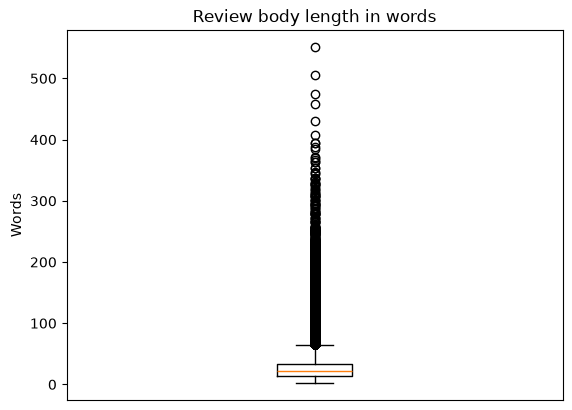

In [216]:
plt.boxplot(n_words)
plt.title('Review body length in words')
plt.ylabel('Words')
plt.xticks([])
plt.show()


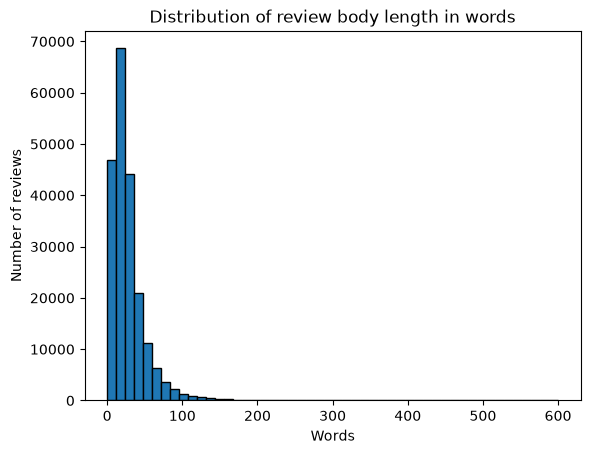

In [217]:
plt.hist(n_words, bins=50, edgecolor='black', range=(0, 600))
plt.title('Distribution of review body length in words')
plt.xlabel('Words')
plt.ylabel('Number of reviews')
plt.show()


In [218]:
n_words_title = df_spanish['title_clean'].apply(lambda x: len(x.split()))
n_words_title.head(5)

400000     2
400001     8
400002    10
400003     3
400004     1
Name: title_clean, dtype: int64

In [219]:
n_words_title.describe()

count    208899.000000
mean          3.321993
std           2.518879
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          28.000000
Name: title_clean, dtype: float64

In [220]:
df_copy['n_words_title'] = n_words_title


df_copy.sort_values(by='n_words_title', ascending=False).head()

,review_id,product_id,reviewer_id,stars,review_body,review_title,language,product_category,split,sentiment,body_clean,title_clean,n_words,n_words_title
535591,es_0224040,product_es_0782427,reviewer_es_0028463,4,Y que en la Tj existe un cargo de 1 Euro extra...,"Todo bien, excepto que la COENZIMA Q10, en el ...",es,drugstore,train,positive,Y que en la Tj existe un cargo de 1 Euro extra...,"Todo bien, excepto que la COENZIMA Q10, en el ...",20,28
477294,es_0383558,product_es_0847177,reviewer_es_0048584,2,Le regalé el reloj a mi marido para reyes de 2...,Le regalé el reloj a mi marido para reyes de 2...,es,sports,train,negative,Le regalé el reloj a mi marido para reyes de 2...,Le regalé el reloj a mi marido para reyes de 2...,74,28
430510,es_0313668,product_es_0464024,reviewer_es_0201404,1,"La verdad es que estoy defraudado con Energy, ...",Compré este tdt en Julio de 2017 y el mando ha...,es,other,train,negative,"La verdad es que estoy defraudado con Energy, ...",Compré este tdt en Julio de 2017 y el mando ha...,55,27
569668,es_0335519,product_es_0920991,reviewer_es_0291767,5,Es un delantal de una tela muy buena vaquera c...,Es un delantal de una tela muy buena vaquera c...,es,apparel,train,positive,Es un delantal de una tela muy buena vaquera c...,Es un delantal de una tela muy buena vaquera c...,30,27
577510,es_0998534,product_es_0900043,reviewer_es_0372529,5,Excelente facil y muy ameno de leer lo recomie...,Ha sido un gran libro muy ameno de leer y de f...,es,digital_ebook_purchase,train,positive,Excelente facil y muy ameno de leer lo recomie...,Ha sido un gran libro muy ameno de leer y de f...,24,27


In [221]:
df_copy.sort_values(by='n_words_title', ascending=False).tail()

,review_id,product_id,reviewer_id,stars,review_body,review_title,language,product_category,split,sentiment,body_clean,title_clean,n_words,n_words_title
400025,es_0116903,product_es_0279338,reviewer_es_0520523,1,Es de plástico uno vale para nada!,Mal,es,industrial_supplies,train,negative,Es de plástico uno vale para nada!,Mal,7,1
400026,es_0981084,product_es_0172765,reviewer_es_0594447,1,"Lo siento, no puedo valorarlo, puesto que la a...",Pilar,es,office_product,train,negative,"Lo siento, no puedo valorarlo, puesto que la a...",Pilar,24,1
400028,es_0987425,product_es_0163066,reviewer_es_0338198,1,Me animé a comprarlo después de leer foros y o...,Inútil,es,lawn_and_garden,train,negative,Me animé a comprarlo después de leer foros y o...,Inútil,23,1
400029,es_0055370,product_es_0220993,reviewer_es_0323765,1,No me ha llegado el producto y no hay forma de...,Estafa,es,beauty,train,negative,No me ha llegado el producto y no hay forma de...,Estafa,29,1
1244968,es_0168684,product_es_0553696,reviewer_es_0796946,5,Cumple con lo establecido,Excelente,es,sports,validation,positive,Cumple con lo establecido,Excelente,4,1


In [222]:
df_copy.sample(10, random_state=seed)

,review_id,product_id,reviewer_id,stars,review_body,review_title,language,product_category,split,sentiment,body_clean,title_clean,n_words,n_words_title
570590,es_0231757,product_es_0182754,reviewer_es_0195405,5,"Cuando lo vi no dude en comprarlo,me parece qu...",Lo compré como complemento de la granja,es,toy,train,positive,"Cuando lo vi no dude en comprarlo,me parece qu...",Lo compré como complemento de la granja,35,7
420162,es_0150762,product_es_0354483,reviewer_es_0923957,1,Llega en mal estado las piezas. El montaje es ...,Revisión de las piezas antes del envio,es,furniture,train,negative,Llega en mal estado las piezas. El montaje es ...,Revisión de las piezas antes del envio,23,7
499206,es_0457292,product_es_0106439,reviewer_es_0593901,3,El dvd está bien pero vino con la caja rota.,Vino con la caja rota,es,other,train,neutral,El dvd está bien pero vino con la caja rota.,Vino con la caja rota,10,5
426599,es_0529522,product_es_0460980,reviewer_es_0850227,1,"la correa no se acopla bien al reloj, encima m...",MALA,es,sports,train,negative,"la correa no se acopla bien al reloj, encima m...",MALA,27,1
500307,es_0613906,product_es_0487562,reviewer_es_0012782,3,"Como tostadora de pan, el pan queda espectacul...",Lo uso exclusivamente como tostadora de pan,es,kitchen,train,neutral,"Como tostadora de pan, el pan queda espectacul...",Lo uso exclusivamente como tostadora de pan,50,7
416966,es_0073956,product_es_0612354,reviewer_es_0326739,1,"LA VERDAD NO LO HE PODIDO NI UTILIZAR, NUNCA E...",NO ENCIENDE...,es,camera,train,negative,"LA VERDAD NO LO HE PODIDO NI UTILIZAR, NUNCA E...",NO ENCIENDE...,20,2
1241321,es_0571648,product_es_0621858,reviewer_es_0645188,2,"Dura igual que la antigua, se descarga rapido",Barata pero se descarga rapido,es,electronics,validation,negative,"Dura igual que la antigua, se descarga rapido",Barata pero se descarga rapido,8,5
566100,es_0428859,product_es_0223040,reviewer_es_0468724,5,Buen precio. Plazo largo pero para tener en el...,Precio bueno plazo largo,es,wireless,train,positive,Buen precio. Plazo largo pero para tener en el...,Precio bueno plazo largo,18,4
562575,es_0939408,product_es_0388291,reviewer_es_0688865,5,"Perfecto envuelto, caja en perfectas condiciones",Envio rápido,es,toy,train,positive,"Perfecto envuelto, caja en perfectas condiciones",Envio rápido,6,2
440281,es_0142231,product_es_0858186,reviewer_es_0357303,2,Tardan en calentarse y se pegan. Cierto es que...,No son tan buenas como parecian,es,home,train,negative,Tardan en calentarse y se pegan. Cierto es que...,No son tan buenas como parecian,22,6


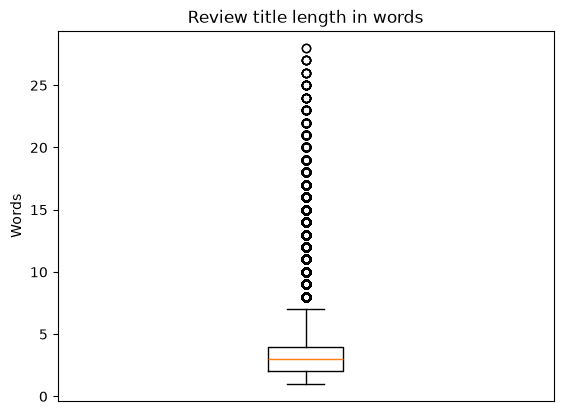

In [223]:
plt.boxplot(n_words_title)
plt.title('Review title length in words')
plt.ylabel('Words')
plt.xticks([])
plt.show()


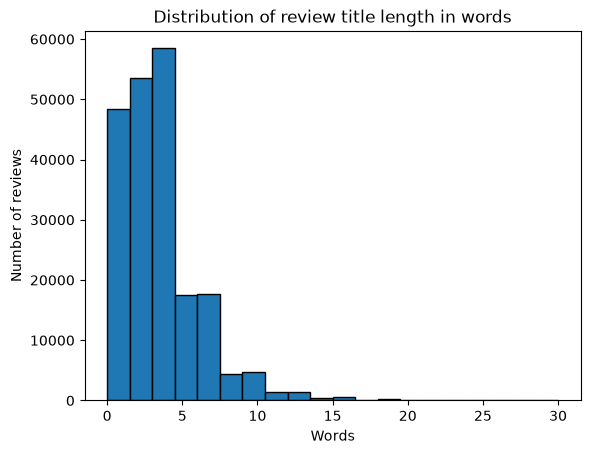

In [224]:
plt.hist(n_words_title, bins=20, edgecolor='black', range=(0, 30))
plt.title('Distribution of review title length in words')
plt.xlabel('Words')
plt.ylabel('Number of reviews')
plt.show()


### Word count: findings

| | `body_clean` | `title_clean` |
|---|---|---|
| Mean | 27.8 | 3.3 |
| Median | 22 | 3 |
| 25th percentile | 13 | 2 |
| 75th percentile | 34 | 4 |
| Maximum | 551 | 28 |
| Minimum | 2 | 1 |

The word counts confirm what the character counts suggested. A median review is 22 words, two
short sentences, and a median title is 3 words. Both distributions are strongly right-skewed:
the histograms show a dense mass near the lower end and a thin tail, and the boxplots mark a
large number of high outliers, which are legitimate long reviews rather than corrupted records.
Half the corpus sits between 13 and 34 words, so the typical review is not just short but
consistently short.

**Decision: no reviews are removed on the basis of length.**

Reading the extremes is what settles it. The shortest bodies contain two words, and those two
words are of the form *muy bien* or *muy mal*: the polarity is stated outright, with no
qualification to be lost. The shortest titles are a single word, such as *Excelente*, *MALA* or
*Devuelto*, and carry the sentiment just as plainly. A short review here is not an
uninformative one; it is a customer who said what they thought in the fewest possible words.

At the other end, the longest review runs to 551 words and the longest title to 28. Reading
them confirms they are ordinary detailed opinions, not concatenation errors or duplicated text.

A minimum-length filter would therefore have removed some of the clearest examples in the
corpus while solving no actual problem. This is the same reasoning applied throughout the
cleaning: the rule is only worth writing if the measurement shows something to fix.

